In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [2]:
# ========================================
# STEP 1: CREATE SIMPLE DATASET
# ========================================

# Creating a simple dataset for binary classification
# Let's predict if a student will pass or fail based on hours studied and attendance

In [3]:
# Features: [Hours_Studied, Attendance_Percentage]
X = np.array([
    [1, 40],
    [2, 50],
    [3, 60],
    [4, 70],
    [5, 75],
    [6, 80],
    [7, 85],
    [8, 90],
    [2, 45],
    [3, 55],
    [5, 70],
    [6, 75],
    [7, 80],
    [8, 85],
    [1, 35],
    [2, 40],
    [4, 65],
    [5, 72],
    [6, 78],
    [7, 82]
])

In [4]:
# Labels: 0 = Fail, 1 = Pass
y = np.array([0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1])

In [5]:
print("Dataset created!")
print(f"Total samples: {len(X)}")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nFirst 5 samples:")
print("Hours | Attendance | Pass/Fail")
for i in range(5):
    print(f"  {X[i][0]}   |    {X[i][1]}     |    {y[i]}")

Dataset created!
Total samples: 20
Features shape: (20, 2)
Labels shape: (20,)

First 5 samples:
Hours | Attendance | Pass/Fail
  1   |    40     |    0
  2   |    50     |    0
  3   |    60     |    0
  4   |    70     |    1
  5   |    75     |    1


In [6]:
# ========================================
# STEP 2: SPLIT DATA INTO TRAIN AND TEST
# ========================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData split completed!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Data split completed!
Training samples: 16
Testing samples: 4


In [7]:
# ========================================
# STEP 3: NORMALIZE THE DATA
# ========================================

# Create scaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform test data (only transform, not fit)
X_test = scaler.transform(X_test)

print(f"\nData normalized!")
print(f"Training data mean: {X_train.mean():.4f}")
print(f"Training data std: {X_train.std():.4f}")


Data normalized!
Training data mean: 0.0000
Training data std: 1.0000


In [8]:
# ========================================
# STEP 4: RESHAPE LABELS FOR NEURAL NETWORK
# ========================================

# Reshape y to be (samples, 1) instead of (samples,)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(f"\nLabels reshaped!")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Labels reshaped!
y_train shape: (16, 1)
y_test shape: (4, 1)


In [9]:
# ========================================
# STEP 5: INITIALIZE NETWORK ARCHITECTURE
# ========================================

# Set random seed for reproducibility
np.random.seed(42)

# Define network structure
input_size = 2      # 2 features (hours, attendance)
hidden_size = 4     # 4 neurons in hidden layer
output_size = 1     # 1 output (pass/fail)

print(f"\n{'='*50}")
print(f"NEURAL NETWORK ARCHITECTURE")
print(f"{'='*50}")
print(f"Input Layer:  {input_size} neurons")
print(f"Hidden Layer: {hidden_size} neurons")
print(f"Output Layer: {output_size} neuron")


NEURAL NETWORK ARCHITECTURE
Input Layer:  2 neurons
Hidden Layer: 4 neurons
Output Layer: 1 neuron


In [10]:
# ========================================
# STEP 6: INITIALIZE WEIGHTS AND BIASES
# ========================================

# Weights between input and hidden layer (2x4 matrix)
weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.5

# Weights between hidden and output layer (4x1 matrix)
weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.5

# Bias for hidden layer (1x4)
bias_hidden = np.zeros((1, hidden_size))

# Bias for output layer (1x1)
bias_output = np.zeros((1, output_size))

print(f"\nWeights initialized!")
print(f"weights_input_hidden shape: {weights_input_hidden.shape}")
print(f"weights_hidden_output shape: {weights_hidden_output.shape}")
print(f"bias_hidden shape: {bias_hidden.shape}")
print(f"bias_output shape: {bias_output.shape}")


Weights initialized!
weights_input_hidden shape: (2, 4)
weights_hidden_output shape: (4, 1)
bias_hidden shape: (1, 4)
bias_output shape: (1, 1)


In [11]:
# ========================================
# STEP 7: DEFINE ACTIVATION FUNCTION (SIGMOID)
# ========================================

# We'll use sigmoid inline, but defining it here for clarity
# sigmoid(x) = 1 / (1 + e^(-x))
# It converts any value to range [0, 1]

print(f"\nActivation function: Sigmoid")


Activation function: Sigmoid


In [12]:
# ========================================
# STEP 8: TRAINING LOOP
# ========================================

# Hyperparameters
learning_rate = 0.1
epochs = 100

# To store loss history
loss_history = []

print(f"\n{'='*50}")
print(f"TRAINING STARTED")
print(f"{'='*50}")
print(f"Learning Rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Training samples: {len(X_train)}")

# Training loop
for epoch in range(epochs):

    # ----------------------------------------
    # FORWARD PROPAGATION
    # ----------------------------------------

    # Layer 1: Input to Hidden
    # z1 = X * W1 + b1
    hidden_layer_input = np.dot(X_train, weights_input_hidden) + bias_hidden

    # Apply activation function (sigmoid)
    # a1 = sigmoid(z1)
    hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))

    # Layer 2: Hidden to Output
    # z2 = a1 * W2 + b2
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output

    # Apply activation function (sigmoid)
    # a2 = sigmoid(z2)
    predicted_output = 1 / (1 + np.exp(-output_layer_input))

    # ----------------------------------------
    # CALCULATE LOSS (Mean Squared Error)
    # ----------------------------------------

    # loss = mean((y - y_pred)^2)
    loss = np.mean((y_train - predicted_output) ** 2)
    loss_history.append(loss)

    # ----------------------------------------
    # BACKWARD PROPAGATION
    # ----------------------------------------

    # Calculate error at output
    # error = y - y_pred
    output_error = y_train - predicted_output

    # Calculate gradient at output layer
    # derivative of sigmoid: f'(x) = f(x) * (1 - f(x))
    output_delta = output_error * predicted_output * (1 - predicted_output)

    # Calculate error at hidden layer
    # backpropagate the error
    hidden_layer_error = output_delta.dot(weights_hidden_output.T)

    # Calculate gradient at hidden layer
    hidden_layer_delta = hidden_layer_error * hidden_layer_output * (1 - hidden_layer_output)

    # ----------------------------------------
    # UPDATE WEIGHTS AND BIASES
    # ----------------------------------------

    # Update weights between hidden and output
    weights_hidden_output += hidden_layer_output.T.dot(output_delta) * learning_rate

    # Update bias for output layer
    bias_output += np.sum(output_delta, axis=0, keepdims=True) * learning_rate

    # Update weights between input and hidden
    weights_input_hidden += X_train.T.dot(hidden_layer_delta) * learning_rate

    # Update bias for hidden layer
    bias_hidden += np.sum(hidden_layer_delta, axis=0, keepdims=True) * learning_rate

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss:.6f}")

print(f"\n{'='*50}")
print(f"TRAINING COMPLETED!")
print(f"{'='*50}")
print(f"Final Loss: {loss:.6f}")



TRAINING STARTED
Learning Rate: 0.1
Epochs: 100
Training samples: 16
Epoch 100/100 - Loss: 0.055086

TRAINING COMPLETED!
Final Loss: 0.055086



Training loss plot saved!


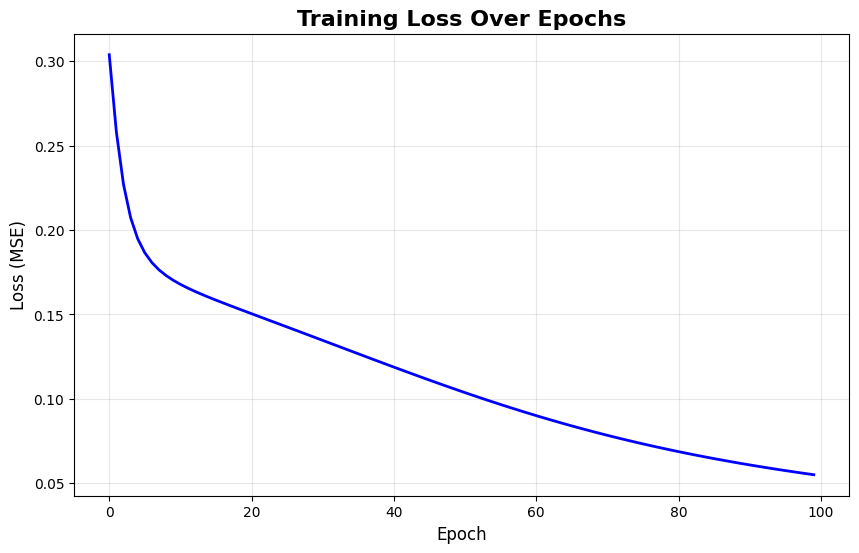

In [13]:
# ========================================
# STEP 9: PLOT TRAINING LOSS
# ========================================

plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Training Loss Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
print(f"\nTraining loss plot saved!")


In [14]:
# ========================================
# STEP 10: MAKE PREDICTIONS ON TRAINING DATA
# ========================================

# Forward pass on training data
hidden_layer_input_train = np.dot(X_train, weights_input_hidden) + bias_hidden
hidden_layer_output_train = 1 / (1 + np.exp(-hidden_layer_input_train))
output_layer_input_train = np.dot(hidden_layer_output_train, weights_hidden_output) + bias_output
train_predictions_prob = 1 / (1 + np.exp(-output_layer_input_train))

# Convert probabilities to binary predictions (0 or 1)
train_predictions = (train_predictions_prob > 0.5).astype(int)

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)

print(f"\n{'='*50}")
print(f"TRAINING SET EVALUATION")
print(f"{'='*50}")
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")


TRAINING SET EVALUATION
Training Accuracy: 100.00%


In [15]:
# ========================================
# STEP 11: MAKE PREDICTIONS ON TEST DATA
# ========================================

# Forward pass on test data
hidden_layer_input_test = np.dot(X_test, weights_input_hidden) + bias_hidden
hidden_layer_output_test = 1 / (1 + np.exp(-hidden_layer_input_test))
output_layer_input_test = np.dot(hidden_layer_output_test, weights_hidden_output) + bias_output
test_predictions_prob = 1 / (1 + np.exp(-output_layer_input_test))

# Convert probabilities to binary predictions
test_predictions = (test_predictions_prob > 0.5).astype(int)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"\n{'='*50}")
print(f"TEST SET EVALUATION")
print(f"{'='*50}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


TEST SET EVALUATION
Test Accuracy: 100.00%


In [16]:
# ========================================
# STEP 12: DETAILED EVALUATION METRICS
# ========================================

# Confusion Matrix
cm = confusion_matrix(y_test, test_predictions)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, test_predictions, target_names=['Fail', 'Pass']))


Confusion Matrix:
[[3 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         3
        Pass       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [17]:
# ========================================
# STEP 13: VISUALIZE PREDICTIONS
# ========================================

print(f"\n{'='*50}")
print(f"TEST SET PREDICTIONS")
print(f"{'='*50}")
print(f"Actual | Predicted | Probability")
print(f"-" * 40)
for i in range(len(y_test)):
    actual = "Pass" if y_test[i][0] == 1 else "Fail"
    predicted = "Pass" if test_predictions[i][0] == 1 else "Fail"
    prob = test_predictions_prob[i][0]
    print(f"  {actual:4s} |   {predicted:4s}    |   {prob:.4f}")



TEST SET PREDICTIONS
Actual | Predicted | Probability
----------------------------------------
  Fail |   Fail    |   0.2679
  Pass |   Pass    |   0.8065
  Fail |   Fail    |   0.2795
  Fail |   Fail    |   0.3169


In [18]:
# ========================================
# STEP 14: SAVE THE MODEL
# ========================================

# Create a dictionary to store all model parameters
model = {
    'weights_input_hidden': weights_input_hidden,
    'weights_hidden_output': weights_hidden_output,
    'bias_hidden': bias_hidden,
    'bias_output': bias_output,
    'scaler': scaler,
    'input_size': input_size,
    'hidden_size': hidden_size,
    'output_size': output_size
}

# Save model to file
with open('ann_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print(f"\n{'='*50}")
print(f"MODEL SAVED!")
print(f"{'='*50}")
print(f"Model saved to: ann_model.pkl")


MODEL SAVED!
Model saved to: ann_model.pkl


In [19]:
# ========================================
# STEP 15: LOAD MODEL AND PREDICT ON NEW DATA
# ========================================

# Load the saved model
with open('ann_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print(f"\nModel loaded successfully!")

# Extract parameters from loaded model
weights_input_hidden_loaded = loaded_model['weights_input_hidden']
weights_hidden_output_loaded = loaded_model['weights_hidden_output']
bias_hidden_loaded = loaded_model['bias_hidden']
bias_output_loaded = loaded_model['bias_output']
scaler_loaded = loaded_model['scaler']



Model loaded successfully!


In [20]:
# ========================================
# STEP 16: PREDICT ON COMPLETELY NEW/UNSEEN DATA
# ========================================

# Create new unseen data
# Format: [Hours_Studied, Attendance_Percentage]
new_data = np.array([
    [3, 55],   # Student 1
    [7, 85],   # Student 2
    [2, 40],   # Student 3
    [6, 80],   # Student 4
    [1, 30]    # Student 5
])

print(f"\n{'='*50}")
print(f"PREDICTIONS ON NEW UNSEEN DATA")
print(f"{'='*50}")

# Normalize the new data using the same scaler
new_data_normalized = scaler_loaded.transform(new_data)

# Forward pass on new data
hidden_input_new = np.dot(new_data_normalized, weights_input_hidden_loaded) + bias_hidden_loaded
hidden_output_new = 1 / (1 + np.exp(-hidden_input_new))
output_input_new = np.dot(hidden_output_new, weights_hidden_output_loaded) + bias_output_loaded
new_predictions_prob = 1 / (1 + np.exp(-output_input_new))

# Convert to binary predictions
new_predictions = (new_predictions_prob > 0.5).astype(int)

# Display predictions
print(f"\nHours | Attendance | Probability | Prediction")
print(f"-" * 55)
for i in range(len(new_data)):
    hours = new_data[i][0]
    attendance = new_data[i][1]
    prob = new_predictions_prob[i][0]
    pred = "Pass" if new_predictions[i][0] == 1 else "Fail"
    print(f"  {hours}   |    {attendance}      |    {prob:.4f}    |    {pred}")


PREDICTIONS ON NEW UNSEEN DATA

Hours | Attendance | Probability | Prediction
-------------------------------------------------------
  3   |    55      |    0.3903    |    Fail
  7   |    85      |    0.9453    |    Pass
  2   |    40      |    0.2795    |    Fail
  6   |    80      |    0.9148    |    Pass
  1   |    30      |    0.2516    |    Fail



Decision boundary plot saved!


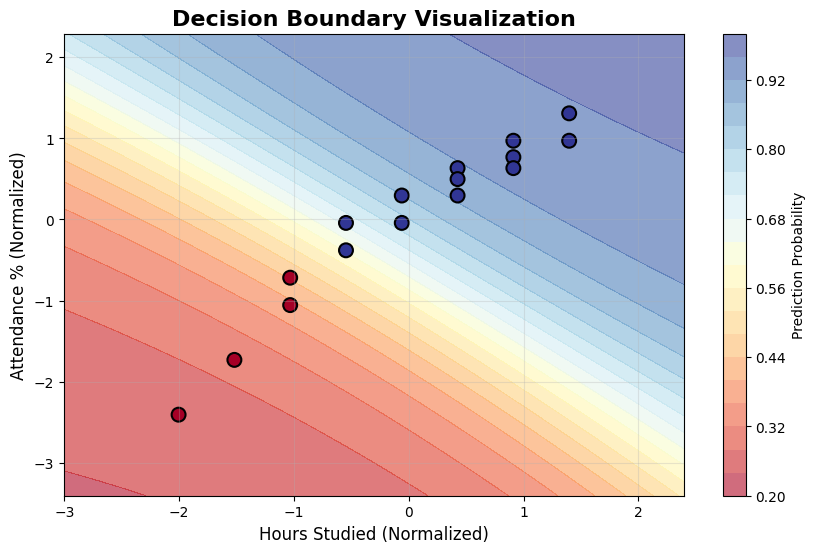

In [21]:
# ========================================
# STEP 17: VISUALIZE DECISION BOUNDARY
# ========================================

# Create a mesh grid for visualization
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Make predictions on grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
hidden_grid = np.dot(grid_points, weights_input_hidden) + bias_hidden
hidden_grid = 1 / (1 + np.exp(-hidden_grid))
output_grid = np.dot(hidden_grid, weights_hidden_output) + bias_output
Z = 1 / (1 + np.exp(-output_grid))
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
plt.colorbar(label='Prediction Probability')

# Plot training points
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                     cmap='RdYlBu', edgecolors='black', s=100, linewidth=1.5)
plt.xlabel('Hours Studied (Normalized)', fontsize=12)
plt.ylabel('Attendance % (Normalized)', fontsize=12)
plt.title('Decision Boundary Visualization', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
print(f"\nDecision boundary plot saved!")

In [22]:
# ========================================
# FINAL SUMMARY
# ========================================

print(f"\n{'='*60}")
print(f"COMPLETE ANN IMPLEMENTATION SUMMARY")
print(f"{'='*60}")
print(f"✓ Dataset: 20 samples (student performance)")
print(f"✓ Features: Hours studied, Attendance percentage")
print(f"✓ Target: Pass/Fail (binary classification)")
print(f"✓ Architecture: {input_size} → {hidden_size} → {output_size}")
print(f"✓ Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"✓ Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"✓ Model saved: ann_model.pkl")
print(f"✓ Predictions on new data: Completed")
print(f"✓ Visualizations: 2 plots saved")
print(f"{'='*60}")
print(f"\n✅ ALL STEPS COMPLETED SUCCESSFULLY!")



COMPLETE ANN IMPLEMENTATION SUMMARY
✓ Dataset: 20 samples (student performance)
✓ Features: Hours studied, Attendance percentage
✓ Target: Pass/Fail (binary classification)
✓ Architecture: 2 → 4 → 1
✓ Training Accuracy: 100.00%
✓ Test Accuracy: 100.00%
✓ Model saved: ann_model.pkl
✓ Predictions on new data: Completed
✓ Visualizations: 2 plots saved

✅ ALL STEPS COMPLETED SUCCESSFULLY!
